# ================================================================
# Phase 7-D — Calibrated Synthetic Analogue Memory Mapping
# ================================================================

"""
Goal:
Map each real EHT observation to calibrated synthetic analogues and summarize
the synthetic memory/event families associated with those analogues.

This phase does NOT claim to recover the true history of M87* or Sgr A*.

It reports conservative analogue distributions:
- closest synthetic datasets
- closest synthetic samples
- available event types
- available event ages
- available physical parameters
- analogue confidence scores

Required previous phases:
- Phase 7-A complete
- Phase 7-B complete
- Phase 7-C complete
"""

In [1]:
# ================================================================
# 1. Imports and setup
# ================================================================

import os
import json
import math
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import Ridge
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Phase 7-D environment ready.")

/home/marwa/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Phase 7-D environment ready.


In [2]:
# ================================================================
# 2. Configuration
# ================================================================

PROJECT_ROOT = Path("/home/marwa/files/phase1_blackhole_generator")
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

PHASE7A_DIR = OUTPUT_DIR / "phase7A_real_observation_consistency"
PHASE7A_TABLE_DIR = PHASE7A_DIR / "tables"

PHASE7B_DIR = OUTPUT_DIR / "phase7B_synthetic_to_real_calibration"
PHASE7B_TABLE_DIR = PHASE7B_DIR / "tables"

PHASE7C_DIR = OUTPUT_DIR / "phase7C_calibration_robustness"
PHASE7C_TABLE_DIR = PHASE7C_DIR / "tables"

PHASE7D_DIR = OUTPUT_DIR / "phase7D_calibrated_memory_mapping"
PHASE7D_TABLE_DIR = PHASE7D_DIR / "tables"
PHASE7D_FIG_DIR = PHASE7D_DIR / "figures"
PHASE7D_REPORT_DIR = PHASE7D_DIR / "reports"

for d in [PHASE7D_DIR, PHASE7D_TABLE_DIR, PHASE7D_FIG_DIR, PHASE7D_REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BRIDGE_DATASET = "phase7A2_grmhd_harvest"

REFERENCE_DATASETS = [
    "phase1_original",
    "phase5_8_morphology",
    "phase5_coupled",
    "phase6_memory",
    "phase7A2_grmhd_harvest",
]

N_NEIGHBORS = 25
TOP_K_FOR_SUMMARY = 10
RIDGE_ALPHA = 1.0
ANALOGUE_DISTANCE_EPS = 1e-8

print("Project root:", PROJECT_ROOT)
print("Phase 7-D output:", PHASE7D_DIR)
print("Bridge dataset:", BRIDGE_DATASET)

Project root: /home/marwa/files/phase1_blackhole_generator
Phase 7-D output: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping
Bridge dataset: phase7A2_grmhd_harvest


In [3]:
# ================================================================
# 3. Utility functions
# ================================================================

def read_csv_required(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    return pd.read_csv(path)

def read_csv_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    return pd.read_csv(path)

def read_json_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    with open(path, "r") as f:
        return json.load(f)

def save_dataframe(df, name):
    path = PHASE7D_TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    return path

def save_plot(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    return path

def latent_columns(df):
    return [c for c in df.columns if c.startswith("latent_")]

def df_to_text(df, max_rows=20):
    if df is None or len(df) == 0:
        return "No data available."
    return df.head(max_rows).to_string(index=False)

def safe_softmax_from_distances(distances):
    distances = np.asarray(distances, dtype=np.float64)
    inv = 1.0 / (distances + ANALOGUE_DISTANCE_EPS)
    weights = inv / inv.sum()
    return weights

def normalize_weights(df, group_col, weight_col="weight"):
    out = df.copy()
    out["normalized_weight"] = out.groupby(group_col)[weight_col].transform(
        lambda x: x / max(x.sum(), ANALOGUE_DISTANCE_EPS)
    )
    return out

In [4]:
# ================================================================
# 4. Load previous phase outputs
# ================================================================

latent_path = PHASE7A_TABLE_DIR / "phase7A_unet_latent_features.csv"
synthetic_index_path = PHASE7A_TABLE_DIR / "phase7A_synthetic_image_index.csv"
real_index_path = PHASE7A_TABLE_DIR / "phase7A_real_image_index.csv"
morphology_path = PHASE7A_TABLE_DIR / "phase7A_morphology_features.csv"

phase7b_pseudo_path = PHASE7B_TABLE_DIR / "phase7B_pseudo_pairs_real_to_bridge.csv"
phase7c_criteria_path = PHASE7C_TABLE_DIR / "phase7C_robustness_criteria.csv"
phase7c_rankings_path = PHASE7C_TABLE_DIR / "phase7C_robustness_rankings.csv"

latent_df = read_csv_required(latent_path)
synthetic_index_df = read_csv_required(synthetic_index_path)
real_index_df = read_csv_required(real_index_path)
morphology_df = read_csv_if_exists(morphology_path)

phase7b_pseudo_df = read_csv_if_exists(phase7b_pseudo_path)
phase7c_criteria_df = read_csv_if_exists(phase7c_criteria_path)
phase7c_rankings_df = read_csv_if_exists(phase7c_rankings_path)

LATENT_COLS = latent_columns(latent_df)

if len(LATENT_COLS) == 0:
    raise RuntimeError("No latent columns found. Run Phase 7-A first.")

synthetic_latent_df = latent_df[latent_df["domain"] == "synthetic"].copy()
real_latent_df = latent_df[latent_df["domain"] != "synthetic"].copy()

bridge_latent_df = synthetic_latent_df[
    synthetic_latent_df["dataset_name"] == BRIDGE_DATASET
].copy()

if len(real_latent_df) == 0:
    raise RuntimeError("No real observations found in latent table.")

if len(bridge_latent_df) == 0:
    raise RuntimeError(f"No bridge dataset rows found: {BRIDGE_DATASET}")

print("Latent rows:", len(latent_df))
print("Synthetic latent rows:", len(synthetic_latent_df))
print("Real latent rows:", len(real_latent_df))
print("Bridge rows:", len(bridge_latent_df))
print("Latent dimensions:", len(LATENT_COLS))

display(real_latent_df[["sample_id", "dataset_name", "image_path"]])

Latent rows: 2508
Synthetic latent rows: 2500
Real latent rows: 8
Bridge rows: 500
Latent dimensions: 512


,sample_id,dataset_name,image_path
2500,m87_2017,real_observations,/home/marwa/files/phase1_blackhole_generator/d...
2501,m87_2018,real_observations,/home/marwa/files/phase1_blackhole_generator/d...
2502,m87_2019_first_image,real_observations,/home/marwa/files/phase1_blackhole_generator/d...
2503,m87_2021,real_observations,/home/marwa/files/phase1_blackhole_generator/d...
2504,m87_2021_polarization,real_observations,/home/marwa/files/phase1_blackhole_generator/d...
2505,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,real_observations,/home/marwa/files/phase1_blackhole_generator/d...
2506,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,real_observations,/home/marwa/files/phase1_blackhole_generator/d...
2507,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,real_observations,/home/marwa/files/phase1_blackhole_generator/d...


In [5]:
# ================================================================
# 5. Load available synthetic metadata
# ================================================================

"""
This cell tries to recover synthetic memory/event metadata from multiple possible files.

The project has several phases, and metadata naming may differ.
This cell is intentionally flexible.
"""

candidate_metadata_files = [
    DATA_ROOT / "dataset_phase6_memory_persistence" / "params_table.csv",
    DATA_ROOT / "dataset_phase6_memory_persistence" / "metadata.csv",
    DATA_ROOT / "dataset_phase6_memory_persistence" / "manifest.csv",
    DATA_ROOT / "grmhd_simulations" / "phase7A2_grmhd_harvest" / "params_table.csv",
    DATA_ROOT / "grmhd_simulations" / "phase7A2_grmhd_harvest" / "metadata.csv",
    DATA_ROOT / "grmhd_simulations" / "phase7A2_grmhd_harvest" / "manifest.csv",
]

metadata_frames = []

for p in candidate_metadata_files:
    df = read_csv_if_exists(p)
    if df is not None:
        temp = df.copy()
        temp["metadata_source"] = str(p)
        metadata_frames.append(temp)
        print("Loaded metadata:", p, "rows:", len(temp))

if metadata_frames:
    raw_metadata_df = pd.concat(metadata_frames, ignore_index=True)
else:
    raw_metadata_df = pd.DataFrame()
    print("No external metadata files found. The mapping will use sample_id and dataset_name only.")

display(raw_metadata_df.head() if len(raw_metadata_df) else raw_metadata_df)

Loaded metadata: /home/marwa/files/phase1_blackhole_generator/data/dataset_phase6_memory_persistence/params_table.csv rows: 1120
Loaded metadata: /home/marwa/files/phase1_blackhole_generator/data/grmhd_simulations/phase7A2_grmhd_harvest/params_table.csv rows: 1206


,mass,spin_base,accretion_base,jet_base,turbulence_base,luminosity_base,observer_angle,camera_yaw,camera_pitch,camera_distance,...,spin_proxy,inclination_deg,magnetic_state,accretion_rate_proxy,jet_power_proxy,electron_temperature_proxy,turbulence_proxy,optical_depth_proxy,dataset_name,image_size
0,10.701978,0.773896,0.478638,0.326458,0.230384,0.486240,0.436469,0.330855,-0.153351,6.836295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12.450652,0.907840,1.100640,0.532531,0.154680,0.612558,42.129864,0.326721,-0.099558,5.374476,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13.883923,0.536270,0.855293,0.360879,0.564212,0.398242,72.902503,-0.041671,0.143898,4.581893,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,13.443942,0.510448,1.133776,0.401334,0.267895,1.094901,5.160053,0.141838,-0.155945,5.614198,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6.499732,0.256092,0.679266,0.646034,0.321586,0.847696,71.984299,0.219969,-0.079398,4.618977,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# ================================================================
# 6. Build synthetic metadata table
# ================================================================

synthetic_meta_df = synthetic_latent_df[
    ["domain", "dataset_name", "sample_id", "image_path"]
].copy()

# Add metadata if matching columns exist.
if len(raw_metadata_df):
    possible_id_cols = ["sample_id", "id", "image_id", "filename", "file_stem"]

    metadata_id_col = None
    for c in possible_id_cols:
        if c in raw_metadata_df.columns:
            metadata_id_col = c
            break

    if metadata_id_col is not None:
        meta = raw_metadata_df.copy()
        if metadata_id_col != "sample_id":
            meta["sample_id"] = meta[metadata_id_col].astype(str)

        # Keep only non-duplicated sample_id rows.
        meta = meta.drop_duplicates(subset=["sample_id"], keep="first")

        synthetic_meta_df = synthetic_meta_df.merge(
            meta,
            on="sample_id",
            how="left",
            suffixes=("", "_meta"),
        )
    else:
        print("Metadata exists but no recognizable sample-id column was found.")

# Derive family columns when absent.
if "event_type" not in synthetic_meta_df.columns:
    synthetic_meta_df["event_type"] = np.nan

if "event_age" not in synthetic_meta_df.columns:
    synthetic_meta_df["event_age"] = np.nan

if "memory_family" not in synthetic_meta_df.columns:
    synthetic_meta_df["memory_family"] = synthetic_meta_df["event_type"]

# Fallback labels for non-memory datasets.
synthetic_meta_df["event_type_filled"] = synthetic_meta_df["event_type"].fillna(
    synthetic_meta_df["dataset_name"]
)

synthetic_meta_df["memory_family_filled"] = synthetic_meta_df["memory_family"].fillna(
    synthetic_meta_df["dataset_name"]
)

display(synthetic_meta_df.head())
print("Synthetic metadata rows:", len(synthetic_meta_df))

synthetic_meta_path = save_dataframe(synthetic_meta_df, "phase7D_synthetic_metadata_resolved")
print("Saved:", synthetic_meta_path)

,domain,dataset_name,sample_id,image_path,mass,spin_base,accretion_base,jet_base,turbulence_base,luminosity_base,...,accretion_rate_proxy,jet_power_proxy,electron_temperature_proxy,turbulence_proxy,optical_depth_proxy,dataset_name_meta,image_size,memory_family,event_type_filled,memory_family_filled
0,synthetic,phase1_original,bh_0001,/home/marwa/files/phase1_blackhole_generator/d...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,phase1_original,phase1_original
1,synthetic,phase1_original,bh_0002,/home/marwa/files/phase1_blackhole_generator/d...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,phase1_original,phase1_original
2,synthetic,phase1_original,bh_0003,/home/marwa/files/phase1_blackhole_generator/d...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,phase1_original,phase1_original
3,synthetic,phase1_original,bh_0004,/home/marwa/files/phase1_blackhole_generator/d...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,phase1_original,phase1_original
4,synthetic,phase1_original,bh_0005,/home/marwa/files/phase1_blackhole_generator/d...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,phase1_original,phase1_original


Synthetic metadata rows: 2500
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/tables/phase7D_synthetic_metadata_resolved.csv


In [7]:
# ================================================================
# 7. Standardize latent space
# ================================================================

X_all = latent_df[LATENT_COLS].to_numpy(dtype=np.float32)

scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

meta_df = latent_df[["domain", "dataset_name", "sample_id", "image_path"]].reset_index(drop=True)
scaled_features_df = pd.DataFrame(X_all_scaled, columns=LATENT_COLS)

scaled_latent_df = pd.concat([meta_df, scaled_features_df], axis=1)

real_scaled_df = scaled_latent_df[scaled_latent_df["domain"] != "synthetic"].copy()
synthetic_scaled_df = scaled_latent_df[scaled_latent_df["domain"] == "synthetic"].copy()
bridge_scaled_df = synthetic_scaled_df[synthetic_scaled_df["dataset_name"] == BRIDGE_DATASET].copy()

print("Scaled latent table:", scaled_latent_df.shape)

Scaled latent table: (2508, 516)


In [8]:
# ================================================================
# 8. Refit conservative ridge calibration using all real images
# ================================================================

"""
This is the calibrated mapping used for analogue search.

It is the same logic as Phase 7-B, but the interpretation is constrained by
Phase 7-C's CONDITIONAL_PASS result.
"""

def fit_ridge_from_bridge_pairs(real_df, bridge_df, latent_cols, n_neighbors=10, alpha=1.0):
    X_bridge = bridge_df[latent_cols].to_numpy(dtype=np.float32)
    X_real = real_df[latent_cols].to_numpy(dtype=np.float32)

    nn = NearestNeighbors(
        n_neighbors=min(n_neighbors, len(bridge_df)),
        metric="euclidean",
    )
    nn.fit(X_bridge)

    distances, indices = nn.kneighbors(X_real)

    bridge_reset = bridge_df.reset_index(drop=True)
    real_reset = real_df.reset_index(drop=True)

    X_train = []
    Y_train = []
    pair_rows = []

    for i, real_row in real_reset.iterrows():
        y = real_row[latent_cols].to_numpy(dtype=np.float32)

        for rank, bridge_idx in enumerate(indices[i]):
            synth_row = bridge_reset.iloc[int(bridge_idx)]
            x = synth_row[latent_cols].to_numpy(dtype=np.float32)

            X_train.append(x)
            Y_train.append(y)

            pair_rows.append({
                "real_sample_id": real_row["sample_id"],
                "real_image_path": real_row["image_path"],
                "synthetic_sample_id": synth_row["sample_id"],
                "synthetic_image_path": synth_row["image_path"],
                "rank": rank + 1,
                "precalibration_distance": float(distances[i, rank]),
            })

    X_train = np.vstack(X_train).astype(np.float32)
    Y_train = np.vstack(Y_train).astype(np.float32)

    model = Ridge(alpha=alpha)
    model.fit(X_train, Y_train)

    info = {
        "alpha": float(alpha),
        "n_real": int(len(real_df)),
        "n_bridge": int(len(bridge_df)),
        "n_training_pairs": int(X_train.shape[0]),
        "input_dim": int(X_train.shape[1]),
        "output_dim": int(Y_train.shape[1]),
        "train_r2": float(model.score(X_train, Y_train)),
    }

    return model, pd.DataFrame(pair_rows), info

ridge_model, calibration_pairs_df, ridge_info = fit_ridge_from_bridge_pairs(
    real_df=real_scaled_df,
    bridge_df=bridge_scaled_df,
    latent_cols=LATENT_COLS,
    n_neighbors=N_NEIGHBORS,
    alpha=RIDGE_ALPHA,
)

print(json.dumps(ridge_info, indent=2))
display(calibration_pairs_df.head())

calibration_pairs_path = save_dataframe(calibration_pairs_df, "phase7D_calibration_pseudopairs")
print("Saved:", calibration_pairs_path)

{
  "alpha": 1.0,
  "n_real": 8,
  "n_bridge": 500,
  "n_training_pairs": 200,
  "input_dim": 512,
  "output_dim": 512,
  "train_r2": 0.7849267721176147
}


,real_sample_id,real_image_path,synthetic_sample_id,synthetic_image_path,rank,precalibration_distance
0,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,grmhd_proxy_00418,/home/marwa/files/phase1_blackhole_generator/d...,1,9.588675
1,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,grmhd_proxy_00402,/home/marwa/files/phase1_blackhole_generator/d...,2,9.724499
2,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,grmhd_proxy_00049,/home/marwa/files/phase1_blackhole_generator/d...,3,9.880575
3,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,grmhd_proxy_00177,/home/marwa/files/phase1_blackhole_generator/d...,4,10.283036
4,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,grmhd_proxy_00484,/home/marwa/files/phase1_blackhole_generator/d...,5,10.294189


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/tables/phase7D_calibration_pseudopairs.csv


In [9]:
# ================================================================
# 9. Apply calibration to synthetic latent vectors
# ================================================================

calibrated_scaled_df = scaled_latent_df.copy()

synth_mask = calibrated_scaled_df["domain"] == "synthetic"
X_synth = calibrated_scaled_df.loc[synth_mask, LATENT_COLS].to_numpy(dtype=np.float32)
X_synth_cal = ridge_model.predict(X_synth).astype(np.float32)

calibrated_scaled_df.loc[synth_mask, LATENT_COLS] = X_synth_cal

real_cal_df = calibrated_scaled_df[calibrated_scaled_df["domain"] != "synthetic"].copy()
synth_cal_df = calibrated_scaled_df[calibrated_scaled_df["domain"] == "synthetic"].copy()

print("Calibrated synthetic rows:", len(synth_cal_df))
print("Real rows:", len(real_cal_df))

Calibrated synthetic rows: 2500
Real rows: 8


In [10]:
# ================================================================
# 10. Find calibrated synthetic analogues for each real observation
# ================================================================

X_real_cal = real_cal_df[LATENT_COLS].to_numpy(dtype=np.float32)
X_synth_cal = synth_cal_df[LATENT_COLS].to_numpy(dtype=np.float32)

nn_all = NearestNeighbors(
    n_neighbors=min(N_NEIGHBORS, len(synth_cal_df)),
    metric="euclidean",
)
nn_all.fit(X_synth_cal)

distances, indices = nn_all.kneighbors(X_real_cal)

synth_reset = synth_cal_df.reset_index(drop=True)
real_reset = real_cal_df.reset_index(drop=True)

analogue_rows = []

for i, real_row in real_reset.iterrows():
    dists = distances[i]
    weights = safe_softmax_from_distances(dists)

    for j, synth_idx in enumerate(indices[i]):
        synth_row = synth_reset.iloc[int(synth_idx)]

        analogue_rows.append({
            "real_sample_id": real_row["sample_id"],
            "real_image_path": real_row["image_path"],
            "rank": j + 1,
            "synthetic_dataset": synth_row["dataset_name"],
            "synthetic_sample_id": synth_row["sample_id"],
            "synthetic_image_path": synth_row["image_path"],
            "calibrated_distance": float(dists[j]),
            "analogue_weight": float(weights[j]),
        })

analogue_df = pd.DataFrame(analogue_rows)

analogue_df = analogue_df.merge(
    synthetic_meta_df.drop(columns=["domain", "dataset_name", "image_path"], errors="ignore"),
    left_on="synthetic_sample_id",
    right_on="sample_id",
    how="left",
    suffixes=("", "_meta"),
)

display(analogue_df.head(30))

analogue_path = save_dataframe(analogue_df, "phase7D_calibrated_synthetic_analogues")
print("Saved:", analogue_path)

,real_sample_id,real_image_path,rank,synthetic_dataset,synthetic_sample_id,synthetic_image_path,calibrated_distance,analogue_weight,sample_id,mass,...,accretion_rate_proxy,jet_power_proxy,electron_temperature_proxy,turbulence_proxy,optical_depth_proxy,dataset_name_meta,image_size,memory_family,event_type_filled,memory_family_filled
0,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,1,phase7A2_grmhd_harvest,grmhd_proxy_00007,/home/marwa/files/phase1_blackhole_generator/d...,0.818551,0.082671,grmhd_proxy_00007,NaN,...,0.867800,0.389651,0.427717,0.411046,0.247771,phase7A2_grmhd_harvest,128.0,NaN,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest
1,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,2,phase7A2_grmhd_harvest,grmhd_proxy_00156,/home/marwa/files/phase1_blackhole_generator/d...,0.942567,0.071794,grmhd_proxy_00156,NaN,...,0.765629,0.067933,0.600966,0.817132,0.192986,phase7A2_grmhd_harvest,128.0,NaN,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest
2,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,3,phase7A2_grmhd_harvest,grmhd_proxy_00129,/home/marwa/files/phase1_blackhole_generator/d...,1.059140,0.063892,grmhd_proxy_00129,NaN,...,0.370298,0.192918,0.063944,0.603964,0.690635,phase7A2_grmhd_harvest,128.0,NaN,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest
3,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,4,phase7A2_grmhd_harvest,grmhd_proxy_00371,/home/marwa/files/phase1_blackhole_generator/d...,1.268513,0.053347,grmhd_proxy_00371,NaN,...,0.631695,0.504418,0.320961,0.251049,0.917783,phase7A2_grmhd_harvest,128.0,NaN,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest
4,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,5,phase7A2_grmhd_harvest,grmhd_proxy_00425,/home/marwa/files/phase1_blackhole_generator/d...,1.336612,0.050629,grmhd_proxy_00425,NaN,...,0.756274,0.370336,0.216662,0.315966,0.427990,phase7A2_grmhd_harvest,128.0,NaN,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest
5,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,6,phase7A2_grmhd_harvest,grmhd_proxy_00274,/home/marwa/files/phase1_blackhole_generator/d...,1.385929,0.048827,grmhd_proxy_00274,NaN,...,0.361058,0.492645,0.241578,0.653494,0.755822,phase7A2_grmhd_harvest,128.0,NaN,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest
6,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,7,phase7A2_grmhd_harvest,grmhd_proxy_00409,/home/marwa/files/phase1_blackhole_generator/d...,1.408711,0.048037,grmhd_proxy_00409,NaN,...,0.680234,0.323102,0.208875,0.452658,0.371053,phase7A2_grmhd_harvest,128.0,NaN,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest
7,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,8,phase7A2_grmhd_harvest,grmhd_proxy_00057,/home/marwa/files/phase1_blackhole_generator/d...,1.447542,0.046749,grmhd_proxy_00057,NaN,...,0.603726,0.230464,0.431181,0.561222,0.480269,phase7A2_grmhd_harvest,128.0,NaN,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest
8,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,9,phase7A2_grmhd_harvest,grmhd_proxy_00440,/home/marwa/files/phase1_blackhole_generator/d...,1.507016,0.044904,grmhd_proxy_00440,NaN,...,0.115277,0.788633,0.365397,0.778045,0.452387,phase7A2_grmhd_harvest,128.0,NaN,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest
9,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,10,phase7A2_grmhd_harvest,grmhd_proxy_00017,/home/marwa/files/phase1_blackhole_generator/d...,1.530896,0.044203,grmhd_proxy_00017,NaN,...,0.483979,0.497133,0.508694,0.509541,0.276059,phase7A2_grmhd_harvest,128.0,NaN,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/tables/phase7D_calibrated_synthetic_analogues.csv


In [11]:
# ================================================================
# 11. Real-observation analogue family distributions
# ================================================================

top_df = analogue_df[analogue_df["rank"] <= TOP_K_FOR_SUMMARY].copy()

if "event_type_filled" not in top_df.columns:
    top_df["event_type_filled"] = top_df["synthetic_dataset"]

if "memory_family_filled" not in top_df.columns:
    top_df["memory_family_filled"] = top_df["event_type_filled"]

family_rows = []

for real_id, sub in top_df.groupby("real_sample_id"):
    for family, fam_sub in sub.groupby("memory_family_filled"):
        family_rows.append({
            "real_sample_id": real_id,
            "memory_family": family,
            "n_analogues": len(fam_sub),
            "weight_sum": float(fam_sub["analogue_weight"].sum()),
            "mean_distance": float(fam_sub["calibrated_distance"].mean()),
            "median_distance": float(fam_sub["calibrated_distance"].median()),
        })

family_distribution_df = pd.DataFrame(family_rows)

if len(family_distribution_df):
    family_distribution_df["normalized_weight"] = family_distribution_df.groupby(
        "real_sample_id"
    )["weight_sum"].transform(lambda x: x / max(x.sum(), ANALOGUE_DISTANCE_EPS))

    family_distribution_df = family_distribution_df.sort_values(
        ["real_sample_id", "normalized_weight"],
        ascending=[True, False],
    )

display(family_distribution_df)

family_distribution_path = save_dataframe(
    family_distribution_df,
    "phase7D_memory_family_distribution_by_real_observation",
)
print("Saved:", family_distribution_path)

,real_sample_id,memory_family,n_analogues,weight_sum,mean_distance,median_distance,normalized_weight
0,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,phase7A2_grmhd_harvest,10,0.520131,2.000434,1.985970,1.000000
1,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,phase7A2_grmhd_harvest,10,0.469998,2.911781,2.938940,1.000000
2,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,phase7A2_grmhd_harvest,10,0.506038,2.224467,2.227206,1.000000
3,m87_2017,phase7A2_grmhd_harvest,10,0.555053,1.270548,1.361271,1.000000
7,m87_2018,phase7A2_grmhd_harvest,6,0.553849,0.892570,0.945704,0.618345
4,m87_2018,phase1_original,4,0.113949,2.857707,3.010537,0.127218
5,m87_2018,phase5_8_morphology,4,0.113949,2.857707,3.010537,0.127218
6,m87_2018,phase5_coupled,4,0.113949,2.857707,3.010537,0.127218
8,m87_2019_first_image,phase7A2_grmhd_harvest,10,0.650483,1.395680,1.332349,1.000000
9,m87_2021,phase7A2_grmhd_harvest,10,0.650578,0.999895,1.099015,1.000000


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/tables/phase7D_memory_family_distribution_by_real_observation.csv


In [12]:
# ================================================================
# 12. Dataset-origin distribution by real observation
# ================================================================

dataset_rows = []

for real_id, sub in top_df.groupby("real_sample_id"):
    for dataset_name, ds_sub in sub.groupby("synthetic_dataset"):
        dataset_rows.append({
            "real_sample_id": real_id,
            "synthetic_dataset": dataset_name,
            "n_analogues": len(ds_sub),
            "weight_sum": float(ds_sub["analogue_weight"].sum()),
            "mean_distance": float(ds_sub["calibrated_distance"].mean()),
            "median_distance": float(ds_sub["calibrated_distance"].median()),
        })

dataset_distribution_df = pd.DataFrame(dataset_rows)

if len(dataset_distribution_df):
    dataset_distribution_df["normalized_weight"] = dataset_distribution_df.groupby(
        "real_sample_id"
    )["weight_sum"].transform(lambda x: x / max(x.sum(), ANALOGUE_DISTANCE_EPS))

    dataset_distribution_df = dataset_distribution_df.sort_values(
        ["real_sample_id", "normalized_weight"],
        ascending=[True, False],
    )

display(dataset_distribution_df)

dataset_distribution_path = save_dataframe(
    dataset_distribution_df,
    "phase7D_dataset_origin_distribution_by_real_observation",
)
print("Saved:", dataset_distribution_path)

,real_sample_id,synthetic_dataset,n_analogues,weight_sum,mean_distance,median_distance,normalized_weight
0,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,phase7A2_grmhd_harvest,10,0.520131,2.000434,1.985970,1.000000
1,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,phase7A2_grmhd_harvest,10,0.469998,2.911781,2.938940,1.000000
2,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,phase7A2_grmhd_harvest,10,0.506038,2.224467,2.227206,1.000000
3,m87_2017,phase7A2_grmhd_harvest,10,0.555053,1.270548,1.361271,1.000000
6,m87_2018,phase7A2_grmhd_harvest,6,0.553849,0.892570,0.945704,0.618345
4,m87_2018,phase5_8_morphology,6,0.185221,2.645678,2.645678,0.206791
5,m87_2018,phase5_coupled,6,0.156625,3.069736,3.069736,0.174865
7,m87_2019_first_image,phase7A2_grmhd_harvest,10,0.650483,1.395680,1.332349,1.000000
8,m87_2021,phase7A2_grmhd_harvest,10,0.650578,0.999895,1.099015,1.000000
11,m87_2021_polarization,phase7A2_grmhd_harvest,6,0.553612,0.882002,0.956696,0.624574


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/tables/phase7D_dataset_origin_distribution_by_real_observation.csv


In [13]:
# ================================================================
# 13. Event-age distribution if available
# ================================================================

event_age_distribution_df = pd.DataFrame()

if "event_age" in top_df.columns and top_df["event_age"].notna().any():
    age_df = top_df.dropna(subset=["event_age"]).copy()
    age_df["event_age"] = pd.to_numeric(age_df["event_age"], errors="coerce")
    age_df = age_df.dropna(subset=["event_age"])

    if len(age_df):
        age_rows = []

        for real_id, sub in age_df.groupby("real_sample_id"):
            weights = sub["analogue_weight"].to_numpy(dtype=float)
            ages = sub["event_age"].to_numpy(dtype=float)

            weighted_mean_age = float(np.sum(weights * ages) / max(weights.sum(), ANALOGUE_DISTANCE_EPS))
            weighted_median_age = float(np.median(ages))

            age_rows.append({
                "real_sample_id": real_id,
                "n_age_analogues": len(sub),
                "weighted_mean_event_age": weighted_mean_age,
                "median_event_age": weighted_median_age,
                "min_event_age": float(np.min(ages)),
                "max_event_age": float(np.max(ages)),
            })

        event_age_distribution_df = pd.DataFrame(age_rows)

display(event_age_distribution_df)

event_age_distribution_path = save_dataframe(
    event_age_distribution_df,
    "phase7D_event_age_distribution_by_real_observation",
)
print("Saved:", event_age_distribution_path)

""


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/tables/phase7D_event_age_distribution_by_real_observation.csv


In [14]:
# ================================================================
# 14. Physical-parameter analogue summary if available
# ================================================================

candidate_param_cols = [
    "mass",
    "spin",
    "accretion",
    "jet_power",
    "turbulence",
    "disk_luminosity",
    "inclination",
    "temperature",
    "magnetic_field",
]

available_param_cols = [
    c for c in candidate_param_cols
    if c in top_df.columns and pd.to_numeric(top_df[c], errors="coerce").notna().any()
]

param_summary_rows = []

if available_param_cols:
    for real_id, sub in top_df.groupby("real_sample_id"):
        row = {"real_sample_id": real_id}

        for c in available_param_cols:
            vals = pd.to_numeric(sub[c], errors="coerce")
            valid = vals.notna()

            if valid.any():
                weights = sub.loc[valid, "analogue_weight"].to_numpy(dtype=float)
                x = vals.loc[valid].to_numpy(dtype=float)

                row[f"{c}_weighted_mean"] = float(np.sum(weights * x) / max(weights.sum(), ANALOGUE_DISTANCE_EPS))
                row[f"{c}_median"] = float(np.median(x))
                row[f"{c}_min"] = float(np.min(x))
                row[f"{c}_max"] = float(np.max(x))

        param_summary_rows.append(row)

parameter_summary_df = pd.DataFrame(param_summary_rows)

display(parameter_summary_df)

parameter_summary_path = save_dataframe(
    parameter_summary_df,
    "phase7D_physical_parameter_analogue_summary",
)
print("Saved:", parameter_summary_path)

""


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/tables/phase7D_physical_parameter_analogue_summary.csv


In [15]:
# ================================================================
# 15. Robustness-aware confidence scoring
# ================================================================

"""
Confidence is intentionally conservative.

It combines:
1. Rank concentration: are top analogues from a coherent dataset/family?
2. Distance compactness: are nearest distances low and close together?
3. Phase 7-C status: conditional pass penalizes confidence.
"""

phase7c_status = "UNKNOWN"

if phase7c_criteria_df is not None and len(phase7c_criteria_df):
    n_pass = int(phase7c_criteria_df["passed"].astype(bool).sum())
    n_total = len(phase7c_criteria_df)

    if n_pass == n_total:
        phase7c_status = "PASS"
        robustness_factor = 1.0
    elif n_pass >= max(1, n_total - 1):
        phase7c_status = "CONDITIONAL_PASS"
        robustness_factor = 0.75
    else:
        phase7c_status = "FAIL"
        robustness_factor = 0.35
else:
    robustness_factor = 0.5

confidence_rows = []

for real_id, sub in top_df.groupby("real_sample_id"):
    sub = sub.sort_values("rank").copy()

    weights = sub["analogue_weight"].to_numpy(dtype=float)
    distances = sub["calibrated_distance"].to_numpy(dtype=float)

    dominant_dataset = (
        dataset_distribution_df[dataset_distribution_df["real_sample_id"] == real_id]
        .sort_values("normalized_weight", ascending=False)
        .head(1)
    )

    dominant_family = (
        family_distribution_df[family_distribution_df["real_sample_id"] == real_id]
        .sort_values("normalized_weight", ascending=False)
        .head(1)
    )

    dataset_concentration = float(dominant_dataset["normalized_weight"].iloc[0]) if len(dominant_dataset) else 0.0
    family_concentration = float(dominant_family["normalized_weight"].iloc[0]) if len(dominant_family) else 0.0

    mean_d = float(np.mean(distances))
    min_d = float(np.min(distances))
    std_d = float(np.std(distances))

    distance_compactness = 1.0 / (1.0 + mean_d + std_d)
    weight_concentration = float(np.max(weights))

    confidence = robustness_factor * (
        0.35 * dataset_concentration
        + 0.35 * family_concentration
        + 0.20 * weight_concentration
        + 0.10 * distance_compactness
    )

    confidence_rows.append({
        "real_sample_id": real_id,
        "phase7c_status": phase7c_status,
        "robustness_factor": robustness_factor,
        "dominant_dataset": dominant_dataset["synthetic_dataset"].iloc[0] if len(dominant_dataset) else "",
        "dominant_dataset_weight": dataset_concentration,
        "dominant_memory_family": dominant_family["memory_family"].iloc[0] if len(dominant_family) else "",
        "dominant_memory_family_weight": family_concentration,
        "min_calibrated_distance": min_d,
        "mean_top_distance": mean_d,
        "std_top_distance": std_d,
        "max_analogue_weight": weight_concentration,
        "analogue_confidence_score": confidence,
    })

confidence_df = pd.DataFrame(confidence_rows).sort_values(
    "analogue_confidence_score",
    ascending=False,
)

display(confidence_df)

confidence_path = save_dataframe(confidence_df, "phase7D_analogue_confidence_scores")
print("Saved:", confidence_path)

,real_sample_id,phase7c_status,robustness_factor,dominant_dataset,dominant_dataset_weight,dominant_memory_family,dominant_memory_family_weight,min_calibrated_distance,mean_top_distance,std_top_distance,max_analogue_weight,analogue_confidence_score
6,m87_2021,CONDITIONAL_PASS,0.75,phase7A2_grmhd_harvest,1.000000,phase7A2_grmhd_harvest,1.000000,0.393930,0.999895,0.325969,0.138270,0.577987
5,m87_2019_first_image,CONDITIONAL_PASS,0.75,phase7A2_grmhd_harvest,1.000000,phase7A2_grmhd_harvest,1.000000,0.652663,1.395680,0.508585,0.118692,0.568628
3,m87_2017,CONDITIONAL_PASS,0.75,phase7A2_grmhd_harvest,1.000000,phase7A2_grmhd_harvest,1.000000,0.818551,1.270548,0.234171,0.082671,0.567344
0,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,CONDITIONAL_PASS,0.75,phase7A2_grmhd_harvest,1.000000,phase7A2_grmhd_harvest,1.000000,1.954858,2.000434,0.040541,0.053204,0.557644
2,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,CONDITIONAL_PASS,0.75,phase7A2_grmhd_harvest,1.000000,phase7A2_grmhd_harvest,1.000000,2.123020,2.224467,0.046829,0.052998,0.555876
1,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,CONDITIONAL_PASS,0.75,phase7A2_grmhd_harvest,1.000000,phase7A2_grmhd_harvest,1.000000,2.697181,2.911781,0.114373,0.050659,0.551227
7,m87_2021_polarization,CONDITIONAL_PASS,0.75,phase7A2_grmhd_harvest,0.624574,phase7A2_grmhd_harvest,0.624574,0.595064,2.215363,0.985294,0.132208,0.365587
4,m87_2018,CONDITIONAL_PASS,0.75,phase7A2_grmhd_harvest,0.618345,phase7A2_grmhd_harvest,0.618345,0.646394,2.202661,0.969925,0.123920,0.361193


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/tables/phase7D_analogue_confidence_scores.csv


,domain,dataset_name,sample_id,image_path,pc1,pc2
0,synthetic,phase1_original,bh_0001,/home/marwa/files/phase1_blackhole_generator/d...,20.109850,8.372137
1,synthetic,phase1_original,bh_0002,/home/marwa/files/phase1_blackhole_generator/d...,-49.616367,1.332708
2,synthetic,phase1_original,bh_0003,/home/marwa/files/phase1_blackhole_generator/d...,12.761046,1.241547
3,synthetic,phase1_original,bh_0004,/home/marwa/files/phase1_blackhole_generator/d...,18.622200,3.036940
4,synthetic,phase1_original,bh_0005,/home/marwa/files/phase1_blackhole_generator/d...,-6.302438,2.346190


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/tables/phase7D_calibrated_pca_coordinates.csv


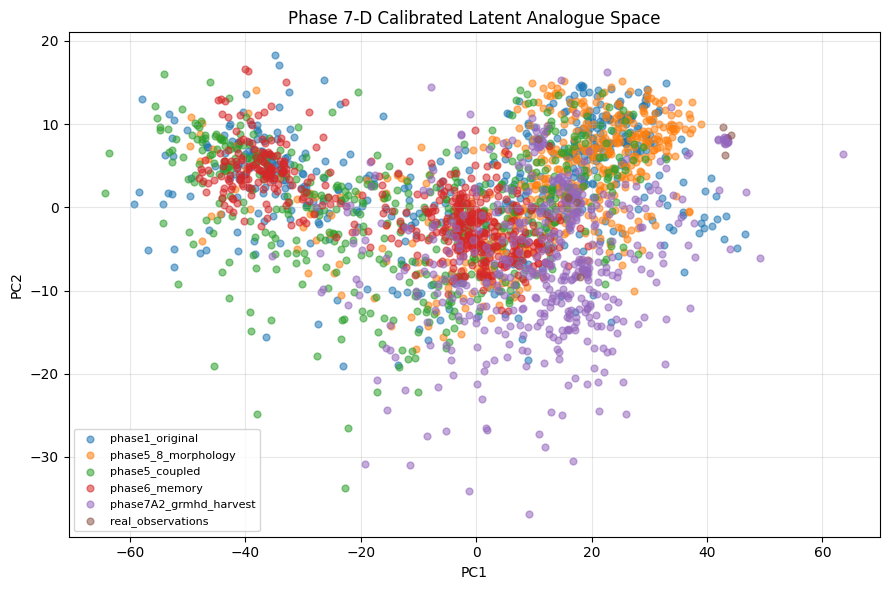

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/figures/phase7D_calibrated_latent_pca.png


In [16]:
# ================================================================
# 16. PCA visualization of calibrated analogue space
# ================================================================

plot_df = calibrated_scaled_df[
    ["domain", "dataset_name", "sample_id", "image_path"] + LATENT_COLS
].copy()

X_plot = plot_df[LATENT_COLS].to_numpy(dtype=np.float32)

pca = PCA(n_components=2, random_state=SEED)
Z = pca.fit_transform(X_plot)

pca_df = plot_df[["domain", "dataset_name", "sample_id", "image_path"]].copy()
pca_df["pc1"] = Z[:, 0]
pca_df["pc2"] = Z[:, 1]

display(pca_df.head())

pca_path = save_dataframe(pca_df, "phase7D_calibrated_pca_coordinates")
print("Saved:", pca_path)

plt.figure(figsize=(9, 6))

for name, sub in pca_df.groupby("dataset_name"):
    plt.scatter(
        sub["pc1"].to_numpy(dtype=float),
        sub["pc2"].to_numpy(dtype=float),
        s=24,
        alpha=0.55,
        label=name,
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Phase 7-D Calibrated Latent Analogue Space")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)

pca_plot_path = save_plot(PHASE7D_FIG_DIR / "phase7D_calibrated_latent_pca.png")
print("Saved:", pca_plot_path)

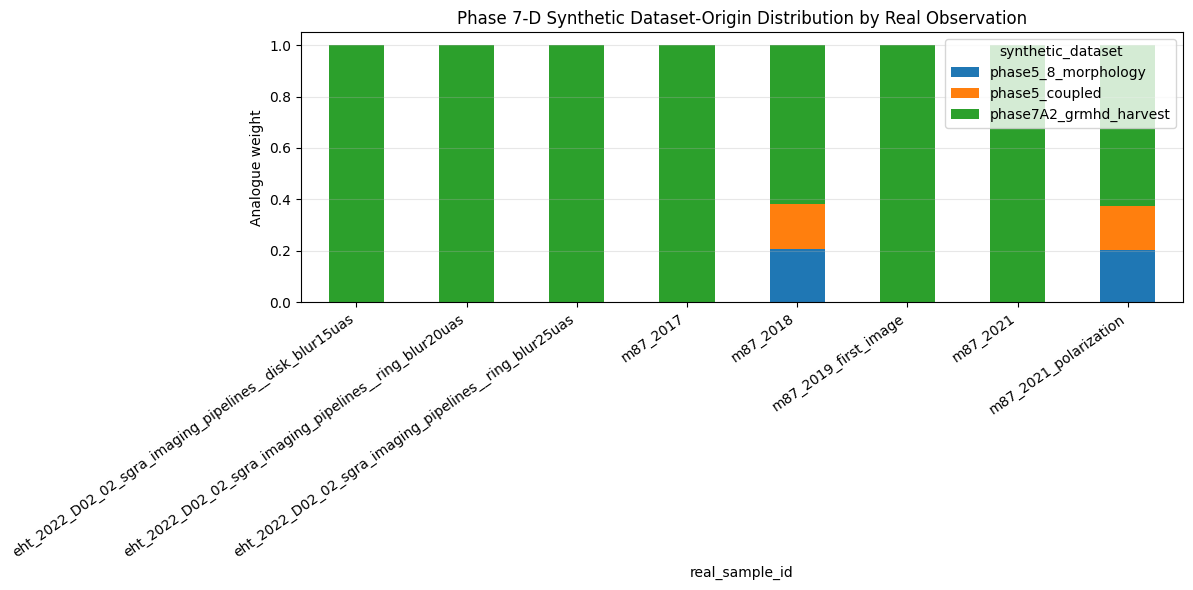

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/figures/phase7D_dataset_origin_distribution.png


In [17]:
# ================================================================
# 17. Plot dataset-origin distributions
# ================================================================

if len(dataset_distribution_df):
    pivot_dataset = dataset_distribution_df.pivot_table(
        index="real_sample_id",
        columns="synthetic_dataset",
        values="normalized_weight",
        fill_value=0.0,
    )

    pivot_dataset = pivot_dataset.reindex(columns=[c for c in REFERENCE_DATASETS if c in pivot_dataset.columns])

    ax = pivot_dataset.plot(kind="bar", stacked=True, figsize=(12, 6))
    ax.set_ylabel("Analogue weight")
    ax.set_title("Phase 7-D Synthetic Dataset-Origin Distribution by Real Observation")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=35, ha="right")

    dataset_dist_plot_path = save_plot(PHASE7D_FIG_DIR / "phase7D_dataset_origin_distribution.png")
    print("Saved:", dataset_dist_plot_path)
else:
    dataset_dist_plot_path = None
    print("No dataset distribution to plot.")

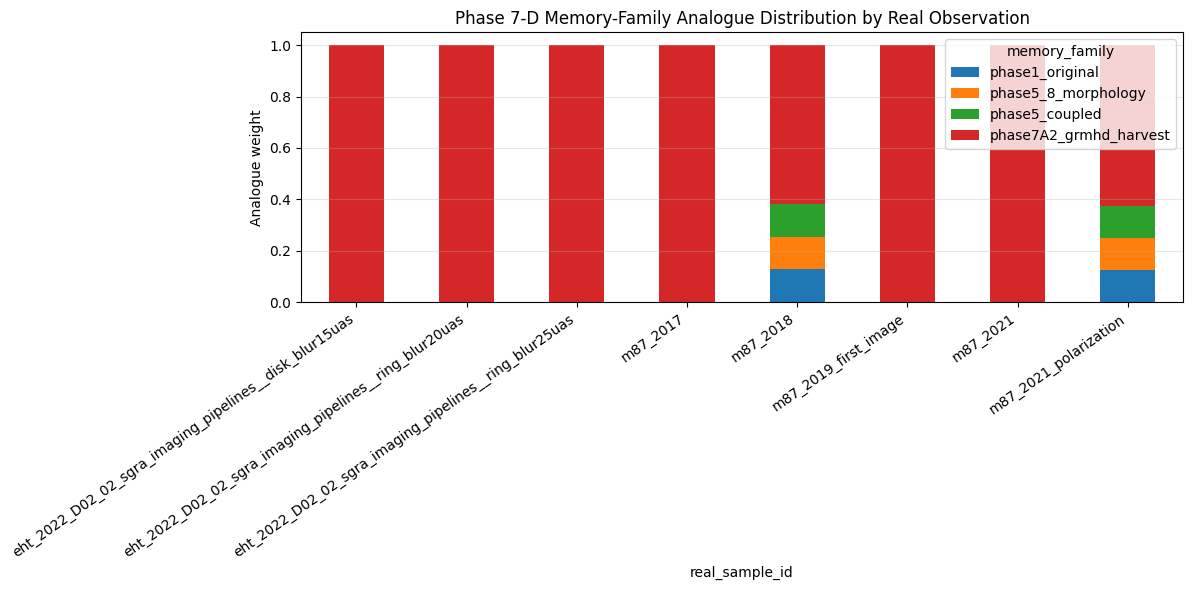

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/figures/phase7D_memory_family_distribution.png


In [18]:
# ================================================================
# 18. Plot memory-family distributions
# ================================================================

if len(family_distribution_df):
    pivot_family = family_distribution_df.pivot_table(
        index="real_sample_id",
        columns="memory_family",
        values="normalized_weight",
        fill_value=0.0,
    )

    ax = pivot_family.plot(kind="bar", stacked=True, figsize=(12, 6))
    ax.set_ylabel("Analogue weight")
    ax.set_title("Phase 7-D Memory-Family Analogue Distribution by Real Observation")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=35, ha="right")

    family_dist_plot_path = save_plot(PHASE7D_FIG_DIR / "phase7D_memory_family_distribution.png")
    print("Saved:", family_dist_plot_path)
else:
    family_dist_plot_path = None
    print("No memory-family distribution to plot.")

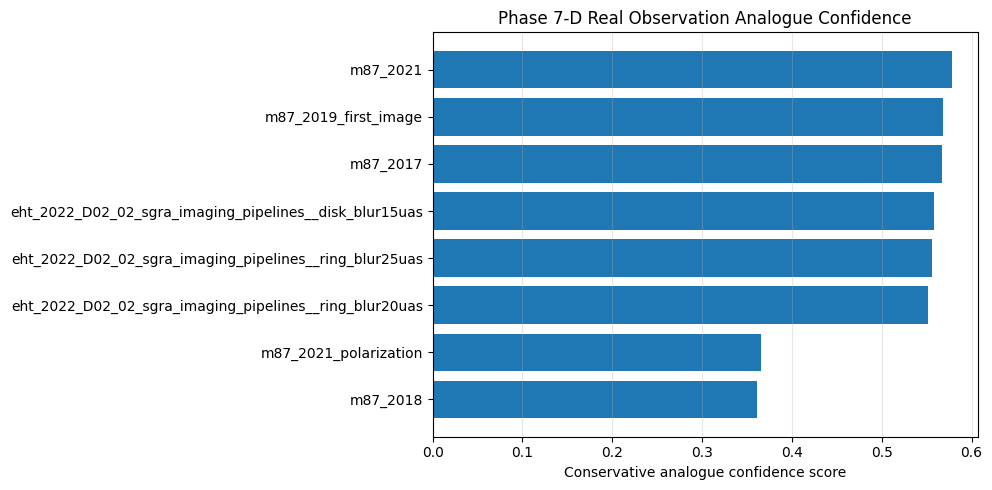

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/figures/phase7D_analogue_confidence_scores.png


In [19]:
# ================================================================
# 19. Plot confidence scores
# ================================================================

if len(confidence_df):
    plot_conf = confidence_df.sort_values("analogue_confidence_score", ascending=True)

    plt.figure(figsize=(10, 5))
    plt.barh(
        plot_conf["real_sample_id"],
        plot_conf["analogue_confidence_score"],
    )

    plt.xlabel("Conservative analogue confidence score")
    plt.title("Phase 7-D Real Observation Analogue Confidence")
    plt.grid(axis="x", alpha=0.3)

    confidence_plot_path = save_plot(PHASE7D_FIG_DIR / "phase7D_analogue_confidence_scores.png")
    print("Saved:", confidence_plot_path)
else:
    confidence_plot_path = None

In [20]:
# ================================================================
# 20. Compact thesis-style result table
# ================================================================

result_rows = []

for _, row in confidence_df.iterrows():
    real_id = row["real_sample_id"]

    fam_sub = family_distribution_df[
        family_distribution_df["real_sample_id"] == real_id
    ].sort_values("normalized_weight", ascending=False)

    ds_sub = dataset_distribution_df[
        dataset_distribution_df["real_sample_id"] == real_id
    ].sort_values("normalized_weight", ascending=False)

    age_sub = event_age_distribution_df[
        event_age_distribution_df["real_sample_id"] == real_id
    ] if len(event_age_distribution_df) else pd.DataFrame()

    top_families = "; ".join(
        [
            f"{r['memory_family']} ({100*r['normalized_weight']:.1f}%)"
            for _, r in fam_sub.head(3).iterrows()
        ]
    )

    top_datasets = "; ".join(
        [
            f"{r['synthetic_dataset']} ({100*r['normalized_weight']:.1f}%)"
            for _, r in ds_sub.head(3).iterrows()
        ]
    )

    if len(age_sub):
        age_text = f"{float(age_sub['weighted_mean_event_age'].iloc[0]):.2f}"
    else:
        age_text = "unavailable"

    result_rows.append({
        "real_sample_id": real_id,
        "dominant_dataset": row["dominant_dataset"],
        "dominant_memory_family": row["dominant_memory_family"],
        "top_dataset_distribution": top_datasets,
        "top_memory_family_distribution": top_families,
        "weighted_mean_event_age": age_text,
        "min_calibrated_distance": row["min_calibrated_distance"],
        "analogue_confidence_score": row["analogue_confidence_score"],
        "interpretation": "synthetic analogue distribution only; not real-history recovery",
    })

thesis_result_df = pd.DataFrame(result_rows)

display(thesis_result_df)

thesis_result_path = save_dataframe(
    thesis_result_df,
    "phase7D_thesis_style_analogue_results",
)
print("Saved:", thesis_result_path)

,real_sample_id,dominant_dataset,dominant_memory_family,top_dataset_distribution,top_memory_family_distribution,weighted_mean_event_age,min_calibrated_distance,analogue_confidence_score,interpretation
0,m87_2021,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest (100.0%),phase7A2_grmhd_harvest (100.0%),unavailable,0.393930,0.577987,synthetic analogue distribution only; not real...
1,m87_2019_first_image,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest (100.0%),phase7A2_grmhd_harvest (100.0%),unavailable,0.652663,0.568628,synthetic analogue distribution only; not real...
2,m87_2017,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest (100.0%),phase7A2_grmhd_harvest (100.0%),unavailable,0.818551,0.567344,synthetic analogue distribution only; not real...
3,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest (100.0%),phase7A2_grmhd_harvest (100.0%),unavailable,1.954858,0.557644,synthetic analogue distribution only; not real...
4,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest (100.0%),phase7A2_grmhd_harvest (100.0%),unavailable,2.123020,0.555876,synthetic analogue distribution only; not real...
5,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest (100.0%),phase7A2_grmhd_harvest (100.0%),unavailable,2.697181,0.551227,synthetic analogue distribution only; not real...
6,m87_2021_polarization,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest (62.5%); phase5_8_morph...,phase7A2_grmhd_harvest (62.5%); phase1_origina...,unavailable,0.595064,0.365587,synthetic analogue distribution only; not real...
7,m87_2018,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest (61.8%); phase5_8_morph...,phase7A2_grmhd_harvest (61.8%); phase1_origina...,unavailable,0.646394,0.361193,synthetic analogue distribution only; not real...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/tables/phase7D_thesis_style_analogue_results.csv


In [21]:
# ================================================================
# 21. Conservative final report
# ================================================================

phase7d_summary = f"""
# Phase 7-D Summary — Calibrated Synthetic Analogue Memory Mapping

## Purpose

Phase 7-D maps real EHT observations to calibrated synthetic analogues.

This phase is deliberately conservative.

It does not claim to recover the true historical accretion behavior of M87* or Sgr A*.
Instead, it reports which synthetic memory/event families are most consistent with
each real observation under the calibrated latent-space bridge developed in Phase 7-B
and stress-tested in Phase 7-C.

## Inputs

Project root:

{PROJECT_ROOT}

Bridge dataset:

{BRIDGE_DATASET}

Real observations:

{len(real_cal_df)}

Synthetic samples:

{len(synth_cal_df)}

Top analogues per real image:

{N_NEIGHBORS}

Top analogues used for summaries:

{TOP_K_FOR_SUMMARY}

Ridge alpha:

{RIDGE_ALPHA}

Phase 7-C robustness status:

{phase7c_status}

## Ridge calibration information

{json.dumps(ridge_info, indent=2)}

## Main analogue results

{df_to_text(thesis_result_df, max_rows=20)}

## Dataset-origin distributions

{df_to_text(dataset_distribution_df, max_rows=30)}

## Memory-family distributions

{df_to_text(family_distribution_df, max_rows=30)}

## Event-age analogue summary

{df_to_text(event_age_distribution_df, max_rows=20)}

## Physical-parameter analogue summary

{df_to_text(parameter_summary_df, max_rows=20)}

## Confidence scores

{df_to_text(confidence_df, max_rows=20)}

## Interpretation

The strongest defensible statement from Phase 7-D is:

Real EHT images can be associated with calibrated synthetic analogue families,
and those associations can be summarized as distributions over synthetic datasets,
memory families, event ages, and physical parameters when available.

The weakest defensible statement is:

These analogue distributions are not direct physical histories of the real black holes.

Because Phase 7-C achieved only a conditional pass, Phase 7-D should be interpreted
as exploratory synthetic-to-real analogue mapping rather than validated inference.

## Recommended next step

The next phase should be Phase 7-E or Phase 8-A:

1. Add more real EHT-like images or GRMHD-rendered images.
2. Repeat Phase 7-C robustness after enlarging the real/external observation set.
3. Only then attempt a publication-level claim about observational memory transfer.

For the thesis or project report, Phase 7-D can be written as:

"Calibrated analogue mapping suggests that real EHT observations occupy regions of
the synthetic memory universe associated with specific GRMHD-inspired morphology
families. However, because real historical labels are unavailable, these mappings
are interpreted as synthetic analogues rather than recovered real histories."
"""

summary_md_path = PHASE7D_REPORT_DIR / "phase7D_calibrated_memory_mapping_summary.md"
summary_txt_path = PHASE7D_REPORT_DIR / "phase7D_calibrated_memory_mapping_summary.txt"

with open(summary_md_path, "w") as f:
    f.write(phase7d_summary)

with open(summary_txt_path, "w") as f:
    f.write(phase7d_summary)

display(Markdown(phase7d_summary[:4500] + "\n\n..."))

print("Saved:", summary_md_path)
print("Saved:", summary_txt_path)


# Phase 7-D Summary — Calibrated Synthetic Analogue Memory Mapping

## Purpose

Phase 7-D maps real EHT observations to calibrated synthetic analogues.

This phase is deliberately conservative.

It does not claim to recover the true historical accretion behavior of M87* or Sgr A*.
Instead, it reports which synthetic memory/event families are most consistent with
each real observation under the calibrated latent-space bridge developed in Phase 7-B
and stress-tested in Phase 7-C.

## Inputs

Project root:

/home/marwa/files/phase1_blackhole_generator

Bridge dataset:

phase7A2_grmhd_harvest

Real observations:

8

Synthetic samples:

2500

Top analogues per real image:

25

Top analogues used for summaries:

10

Ridge alpha:

1.0

Phase 7-C robustness status:

CONDITIONAL_PASS

## Ridge calibration information

{
  "alpha": 1.0,
  "n_real": 8,
  "n_bridge": 500,
  "n_training_pairs": 200,
  "input_dim": 512,
  "output_dim": 512,
  "train_r2": 0.7849267721176147
}

## Main analogue results

                                        real_sample_id       dominant_dataset dominant_memory_family                                                            top_dataset_distribution                                                       top_memory_family_distribution weighted_mean_event_age  min_calibrated_distance  analogue_confidence_score                                                  interpretation
                                              m87_2021 phase7A2_grmhd_harvest phase7A2_grmhd_harvest                                                     phase7A2_grmhd_harvest (100.0%)                                                      phase7A2_grmhd_harvest (100.0%)             unavailable                 0.393930                   0.577987 synthetic analogue distribution only; not real-history recovery
                                  m87_2019_first_image phase7A2_grmhd_harvest phase7A2_grmhd_harvest                                                     phase7A2_grmhd_harvest (100.0%)                                                      phase7A2_grmhd_harvest (100.0%)             unavailable                 0.652663                   0.568628 synthetic analogue distribution only; not real-history recovery
                                              m87_2017 phase7A2_grmhd_harvest phase7A2_grmhd_harvest                                                     phase7A2_grmhd_harvest (100.0%)                                                      phase7A2_grmhd_harvest (100.0%)             unavailable                 0.818551                   0.567344 synthetic analogue distribution only; not real-history recovery
eht_2022_D02_02_sgra_imaging_pipelines__disk_blur15uas phase7A2_grmhd_harvest phase7A2_grmhd_harvest                                                     phase7A2_grmhd_harvest (100.0%)                                                      phase7A2_grmhd_harvest (100.0%)             unavailable                 1.954858                   0.557644 synthetic analogue distribution only; not real-history recovery
eht_2022_D02_02_sgra_imaging_pipelines__ring_blur25uas phase7A2_grmhd_harvest phase7A2_grmhd_harvest                                                     phase7A2_grmhd_harvest (100.0%)                                                      phase7A2_grmhd_harvest (100.0%)             unavailable                 2.123020                   0.555876 synthetic analogue distribution only; not real-history recovery
eht_2022_D02_02_sgra_imaging_pipelines__ring_blur20uas phase7A2_grmhd_harvest phase7A2_grmhd_harvest                                                     phase7A2_grmhd_harvest (100.0%)                                                      phase7A2_grmhd_harvest (100.0%)             unavailable                 2.697181                   0.551227 synthetic analogue distribution only; not real-history recovery
                                 m87_2021_polarization phase7A2_grmhd_harvest phase7A2_grmhd_harvest phase7A2_grmhd_harvest (62.5%); phase5_8_morphology (20.3%); phase5_coupled (17.3%) phase7A2_grmhd_harvest (62.5%); phase1_original (12.5%); phase5_8_morphology (12.5%)             unavailable                 0.595064                   0.365587 synthetic analogue distribution only; not real-history recovery
                                              m87_2018 phase7A2_grmhd_harvest phase7A2_grmhd_harvest phase7A2_grmhd_harvest (61.8%); phase5_8_morphology (20.7%); phase5_coupled (17.5%) phase7A2_grmhd_harvest (61.8%);

...

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/reports/phase7D_calibrated_memory_mapping_summary.md
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/reports/phase7D_calibrated_memory_mapping_summary.txt


In [22]:
# ================================================================
# 22. Final index
# ================================================================

phase7d_index = {
    "created_at": datetime.now().isoformat(),
    "project_root": str(PROJECT_ROOT),
    "phase7A_dir": str(PHASE7A_DIR),
    "phase7B_dir": str(PHASE7B_DIR),
    "phase7C_dir": str(PHASE7C_DIR),
    "phase7D_dir": str(PHASE7D_DIR),
    "bridge_dataset": BRIDGE_DATASET,
    "n_real": int(len(real_cal_df)),
    "n_synthetic": int(len(synth_cal_df)),
    "n_neighbors": int(N_NEIGHBORS),
    "top_k_for_summary": int(TOP_K_FOR_SUMMARY),
    "ridge_alpha": float(RIDGE_ALPHA),
    "phase7c_status": phase7c_status,
    "ridge_info": ridge_info,
    "main_outputs": {
        "synthetic_metadata_resolved": str(synthetic_meta_path),
        "calibration_pseudopairs": str(calibration_pairs_path),
        "calibrated_synthetic_analogues": str(analogue_path),
        "memory_family_distribution": str(family_distribution_path),
        "dataset_origin_distribution": str(dataset_distribution_path),
        "event_age_distribution": str(event_age_distribution_path),
        "physical_parameter_summary": str(parameter_summary_path),
        "confidence_scores": str(confidence_path),
        "pca_coordinates": str(pca_path),
        "thesis_style_results": str(thesis_result_path),
        "summary_md": str(summary_md_path),
        "summary_txt": str(summary_txt_path),
    },
    "figures": {
        "calibrated_pca": str(pca_plot_path),
        "dataset_origin_distribution": str(dataset_dist_plot_path) if dataset_dist_plot_path else None,
        "memory_family_distribution": str(family_dist_plot_path) if family_dist_plot_path else None,
        "confidence_scores": str(confidence_plot_path) if confidence_plot_path else None,
    },
}

index_path = PHASE7D_DIR / "phase7D_index.json"

with open(index_path, "w") as f:
    json.dump(phase7d_index, f, indent=2)

print("=" * 80)
print("Phase 7-D complete")
print("=" * 80)
print("Index:", index_path)
print("Output directory:", PHASE7D_DIR)
print("Tables:", PHASE7D_TABLE_DIR)
print("Figures:", PHASE7D_FIG_DIR)
print("Reports:", PHASE7D_REPORT_DIR)
print("=" * 80)

Phase 7-D complete
Index: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/phase7D_index.json
Output directory: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping
Tables: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/tables
Figures: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/figures
Reports: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/reports
